# GCCR Slack Exploratory Analysis

Exploratory figures for voice distribution, reaction equity, response patterns, network centrality, temporal participation, and geographic diversity. All outputs saved to `artifacts/`.

## Setup

In [1]:
import os
if os.path.basename(os.getcwd()) == "scripts":
    os.chdir("..")


In [2]:
# Install required packages
import subprocess
subprocess.run(["pip", "install", "pandas", "matplotlib", "networkx", "python-louvain", "geopandas", "countrycode", "seaborn"], check=True)


CompletedProcess(args=['pip', 'install', 'pandas', 'matplotlib', 'networkx', 'python-louvain', 'geopandas', 'countrycode', 'seaborn'], returncode=0)

In [3]:
import os
import json
import re
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import networkx as nx
from collections import Counter, defaultdict
from networkx.algorithms import community as nx_comm
import warnings
warnings.filterwarnings("ignore")

# Mako palette matching R: begin=0.3, end=0.9, direction=-1, alpha=0.9
_mako_full = sns.color_palette("mako", as_cmap=True)
_n = 256
_colors = _mako_full(np.linspace(0.9, 0.3, _n))
_colors[:, 3] = 0.9
MAKO = LinearSegmentedColormap.from_list("mako_r_narrow", _colors, N=_n)
C_LOW  = "#A8E1BC"
C_HIGH = "#414081"
C_MID  = "#3DB4AD"
C_MID2 = "#357BA2"
C_4    = ["#A8E1BC", "#3DB4AD", "#357BA2", "#414081"]

def vir(values):
    """Map values to mako palette matching R."""
    values = np.array(values, dtype=float)
    normed = (values - values.min()) / (values.max() - values.min() + 1e-9)
    return [MAKO(v) for v in normed]

def vir_single(val):
    """Single color at position val (0=lightest, 1=darkest)."""
    return MAKO(val)


In [4]:
df = pd.read_csv(os.path.join("data", "slack-explore.csv"))
df["date"] = pd.to_datetime(df["date"])
df = df[df["active"] == True].copy()
df["reactions"] = df["reactions"].apply(lambda x: json.loads(x) if pd.notna(x) else [])
print(f'Total messages: {len(df):,}')
print(f'Active users:   {df["id"].nunique():,}')
print(f'Countries:      {df["country"].nunique()}')


Total messages: 22,309
Active users:   600
Countries:      61


## Exploration: Voice Distribution

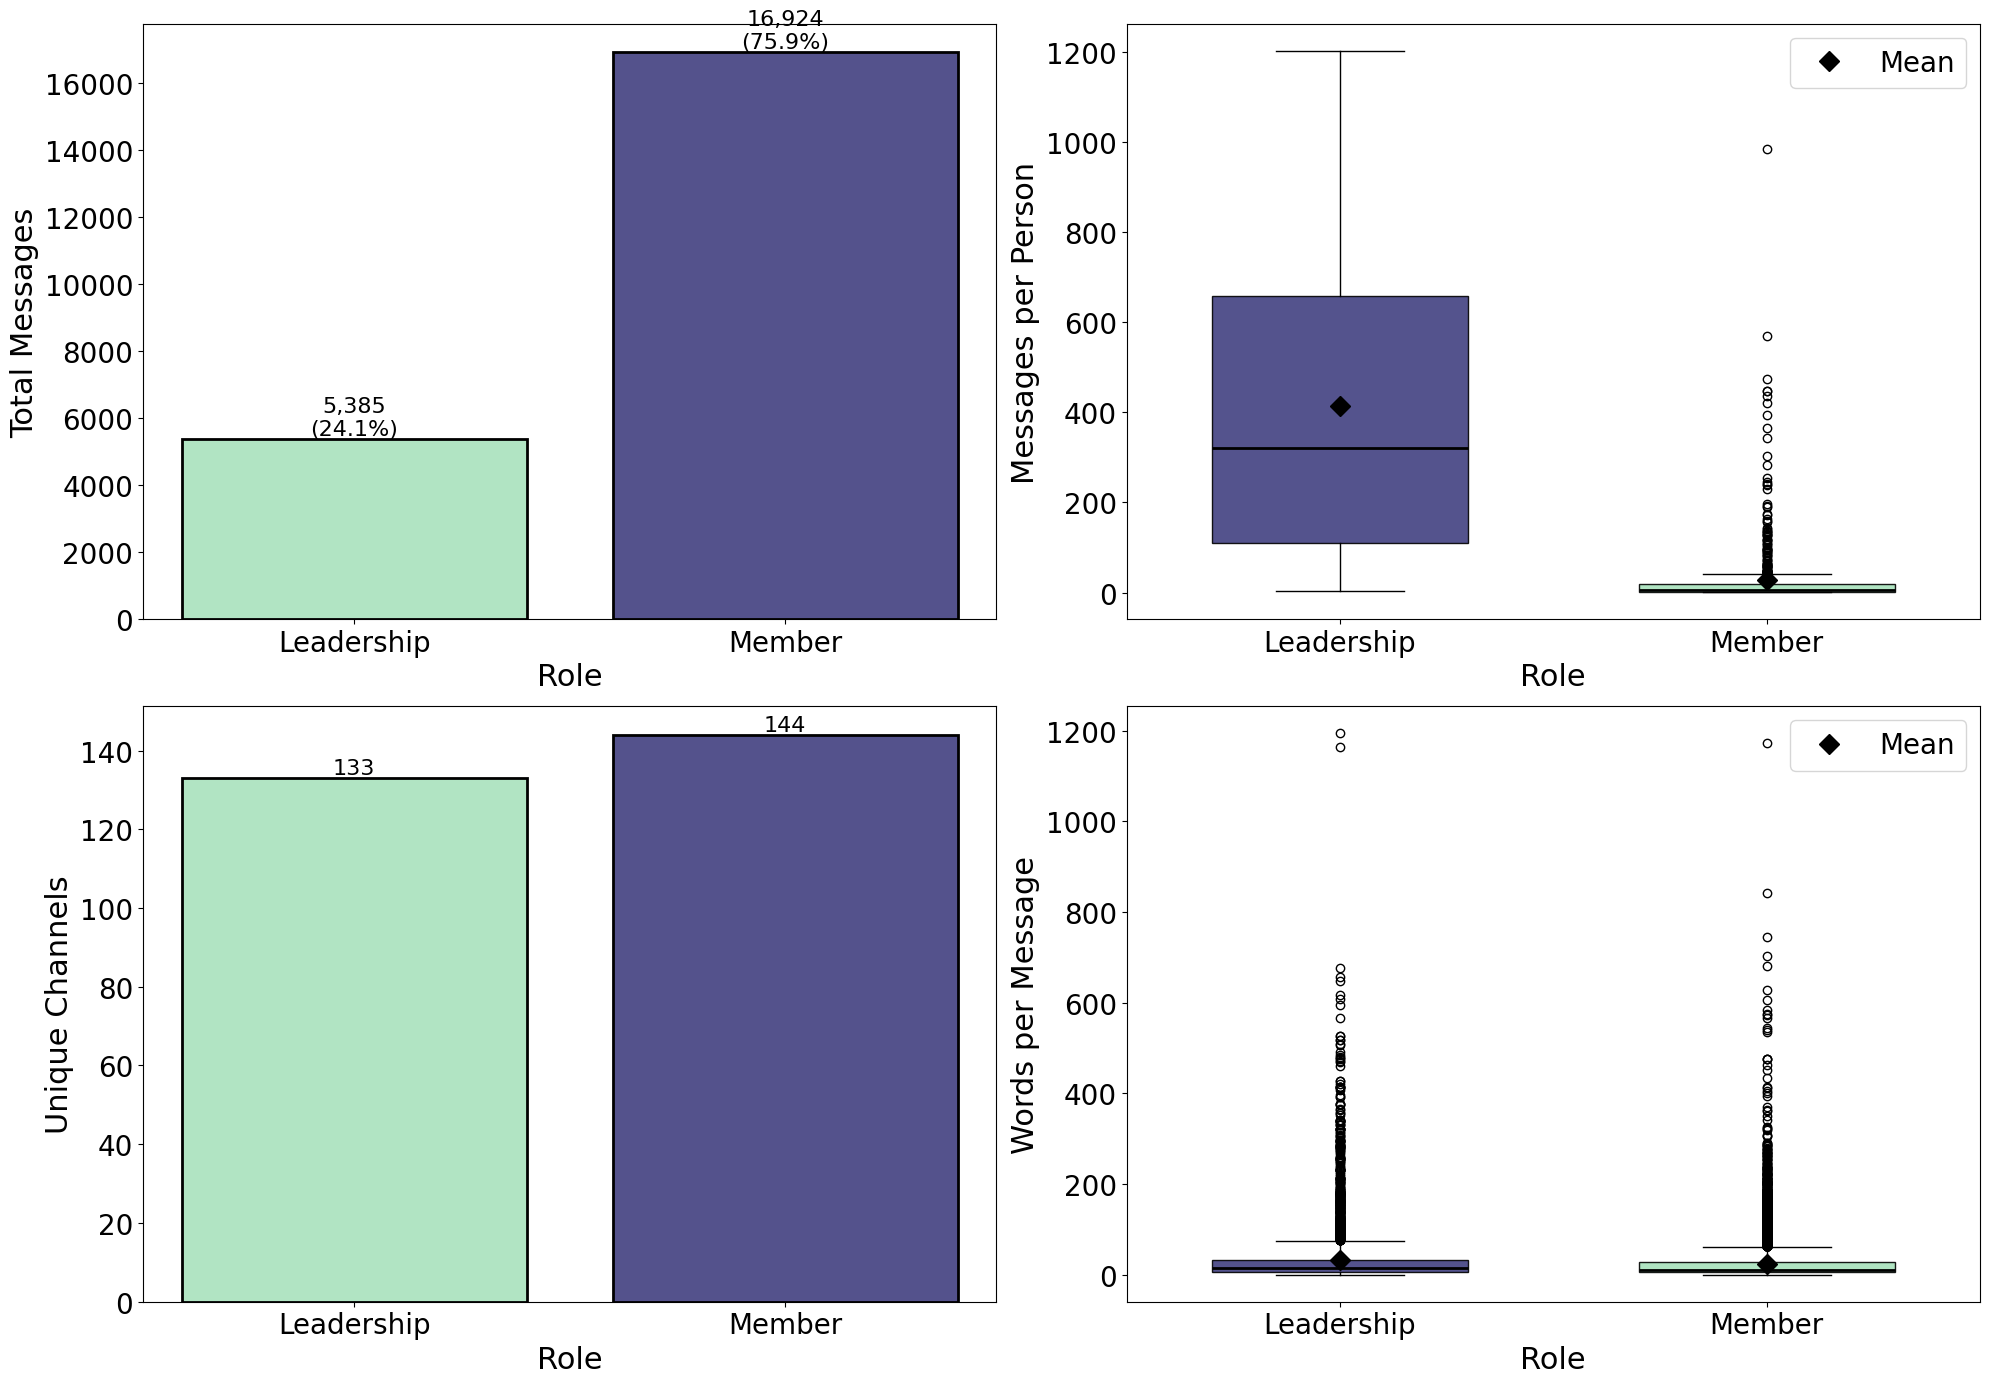

Saved: artifacts/slack-explore-voiceDistribution.png

Voice Distribution Statistics:
  Leadership: 5,385 messages (24.1%)
  Members:    16,924 messages (75.9%)
  Messages per Leadership: 414.2
  Messages per Member:     28.8
  Ratio: 14.37x


In [5]:
role_counts      = df.groupby('role').size()
role_users       = df.groupby('role')['id'].nunique()
msgs_per_capita  = role_counts / role_users
channel_part     = df.groupby('role')['channel'].nunique()
words_by_role    = df.groupby('role')['word_count'].agg(['mean', 'median'])

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Panel A: Total messages (count)
ax = axes[0, 0]
vals = np.array(role_counts.values)
bars = ax.bar(['Leadership', 'Member'], vals, color=vir(vals), edgecolor='black', linewidth=2)
ax.set_xlabel('Role', fontsize=22)
ax.set_ylabel('Total Messages', fontsize=22)
ax.tick_params(axis='both', labelsize=20)
total = sum(vals)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h,
            f'{int(h):,}\n({h/total*100:.1f}%)', ha='center', va='bottom', fontsize=16)

# Panel B: Messages per capita — boxplot with mean diamond
ax = axes[0, 1]
lead_msgs = df[df['role']=='Leadership'].groupby('id').size().values.astype(float)
memb_msgs = df[df['role']=='Member'].groupby('id').size().values.astype(float)
bp = ax.boxplot([lead_msgs, memb_msgs], labels=['Leadership', 'Member'],
                patch_artist=True, widths=0.6)
for patch, col in zip(bp['boxes'], [C_HIGH, C_LOW]):
    patch.set_facecolor(col)
    patch.set_alpha(0.9)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)
means_b = [lead_msgs.mean(), memb_msgs.mean()]
ax.plot([1, 2], means_b, 'D', color='black', markersize=10, label='Mean', zorder=3)
ax.set_xlabel('Role', fontsize=22)
ax.set_ylabel('Messages per Person', fontsize=22)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=20)

# Panel C: Channel participation (count)
ax = axes[1, 0]
vals = np.array(channel_part.values)
bars = ax.bar(['Leadership', 'Member'], vals, color=vir(vals), edgecolor='black', linewidth=2)
ax.set_xlabel('Role', fontsize=22)
ax.set_ylabel('Unique Channels', fontsize=22)
ax.tick_params(axis='both', labelsize=20)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h,
            f'{int(h)}', ha='center', va='bottom', fontsize=16)

# Panel D: Message length — boxplot with mean diamond
ax = axes[1, 1]
lead_wc = df[df['role']=='Leadership']['word_count'].values.astype(float)
memb_wc = df[df['role']=='Member']['word_count'].values.astype(float)
bp = ax.boxplot([lead_wc, memb_wc], labels=['Leadership', 'Member'],
                patch_artist=True, widths=0.6)
for patch, col in zip(bp['boxes'], [C_HIGH, C_LOW]):
    patch.set_facecolor(col)
    patch.set_alpha(0.9)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)
means_d = [lead_wc.mean(), memb_wc.mean()]
ax.plot([1, 2], means_d, 'D', color='black', markersize=10, label='Mean', zorder=3)
ax.set_xlabel('Role', fontsize=22)
ax.set_ylabel('Words per Message', fontsize=22)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=20)

plt.tight_layout()
plt.savefig('artifacts/slack-explore-voiceDistribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: artifacts/slack-explore-voiceDistribution.png')

print(f'\nVoice Distribution Statistics:')
print(f'  Leadership: {role_counts["Leadership"]:,} messages ({role_counts["Leadership"]/total*100:.1f}%)')
print(f'  Members:    {role_counts["Member"]:,} messages ({role_counts["Member"]/total*100:.1f}%)')
print(f'  Messages per Leadership: {msgs_per_capita["Leadership"]:.1f}')
print(f'  Messages per Member:     {msgs_per_capita["Member"]:.1f}')
print(f'  Ratio: {msgs_per_capita["Leadership"]/msgs_per_capita["Member"]:.2f}x')

## Exploration: Reaction Equity

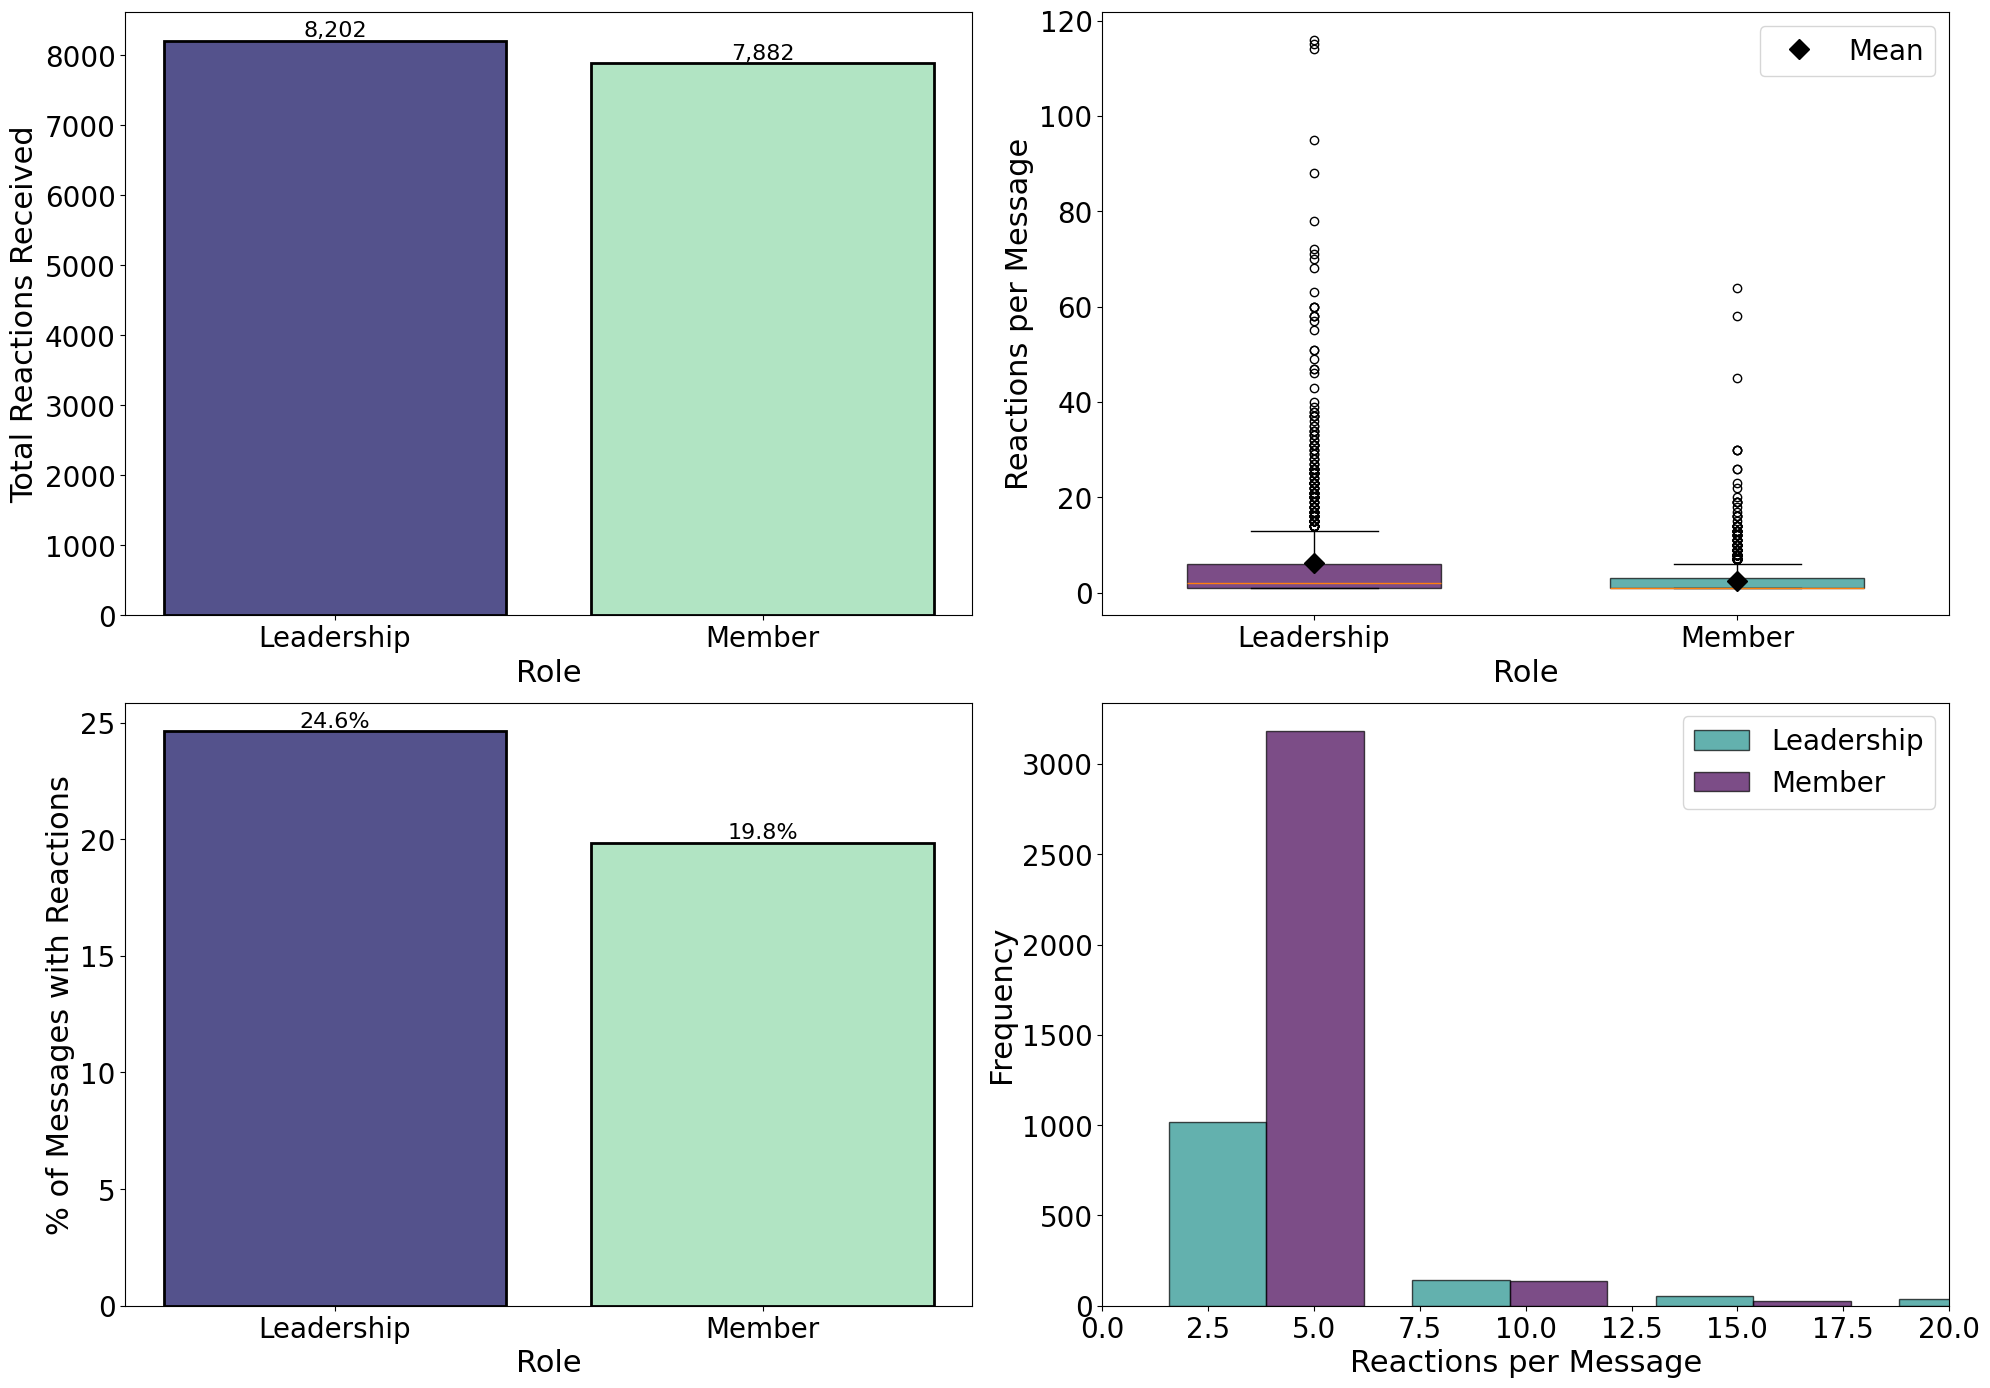

Saved: artifacts/slack-explore-reactionEquity.png

Reaction Equity Statistics:
  Leadership reactions/message: 1.52
  Member reactions/message:     0.47
  Ratio: 3.27x
  % Leadership messages with reactions: 24.6%
  % Member messages with reactions:     19.8%


In [6]:
# Build per-message reaction data
reactions_data = []
for idx, row in df.iterrows():
    if isinstance(row.get('reactions'), list) and row['reactions']:
        total_r = sum(r.get('count', 0) for r in row['reactions'])
        reactions_data.append({'role': row['role'], 'total_reactions': total_r})

reactions_df     = pd.DataFrame(reactions_data)
reactions_by_role = reactions_df.groupby('role')['total_reactions'].agg(['sum', 'mean', 'count'])
messages_by_role  = df.groupby('role').size()
reactions_per_msg = reactions_by_role['sum'] / messages_by_role
pct_with_reactions = reactions_by_role['count'] / messages_by_role * 100

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Panel A: Total reactions (count)
ax = axes[0, 0]
vals = np.array(reactions_by_role['sum'].values)
bars = ax.bar(['Leadership', 'Member'], vals, color=vir(vals), edgecolor='black', linewidth=2)
ax.set_xlabel('Role', fontsize=22)
ax.set_ylabel('Total Reactions Received', fontsize=22)
ax.tick_params(axis='both', labelsize=20)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h,
            f'{int(h):,}', ha='center', va='bottom', fontsize=16)

# Panel B: Reactions per message (mean) — boxplot per editor request
ax = axes[0, 1]
lead_r = reactions_df[reactions_df['role']=='Leadership']['total_reactions']
memb_r = reactions_df[reactions_df['role']=='Member']['total_reactions']
bp = ax.boxplot([lead_r, memb_r], labels=['Leadership', 'Member'],
                patch_artist=True, widths=0.6)
for patch, val in zip(bp['boxes'], [lead_r.median(), memb_r.median()]):
    norm_val = (val - min(lead_r.median(), memb_r.median())) / \
               (max(lead_r.median(), memb_r.median()) - min(lead_r.median(), memb_r.median()) + 1e-9)
    patch.set_facecolor(["#440154", "#21918c"][list(bp["boxes"]).index(patch)])
    patch.set_alpha(0.7)
means = [lead_r.mean(), memb_r.mean()]
ax.plot([1, 2], means, 'D', color='black', markersize=10, label='Mean', zorder=3)
ax.set_xlabel('Role', fontsize=22)
ax.set_ylabel('Reactions per Message', fontsize=22)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=20)

# Panel C: Percentage of messages with reactions (count)
ax = axes[1, 0]
vals = np.array(pct_with_reactions.values)
bars = ax.bar(['Leadership', 'Member'], vals, color=vir(vals), edgecolor='black', linewidth=2)
ax.set_xlabel('Role', fontsize=22)
ax.set_ylabel('% of Messages with Reactions', fontsize=22)
ax.tick_params(axis='both', labelsize=20)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=16)

# Panel D: Distribution of reactions per message
ax = axes[1, 1]
ax.hist([lead_r, memb_r], bins=20,
        label=['Leadership', 'Member'],
        color=["#21918c", "#440154"],
        alpha=0.7, edgecolor='black')
ax.set_xlabel('Reactions per Message', fontsize=22)
ax.set_ylabel('Frequency', fontsize=22)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=20)
ax.set_xlim(0, 20)

plt.tight_layout()
plt.savefig('artifacts/slack-explore-reactionEquity.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: artifacts/slack-explore-reactionEquity.png')

print(f'\nReaction Equity Statistics:')
print(f'  Leadership reactions/message: {reactions_per_msg["Leadership"]:.2f}')
print(f'  Member reactions/message:     {reactions_per_msg["Member"]:.2f}')
print(f'  Ratio: {reactions_per_msg["Leadership"]/reactions_per_msg["Member"]:.2f}x')
print(f'  % Leadership messages with reactions: {pct_with_reactions["Leadership"]:.1f}%')
print(f'  % Member messages with reactions:     {pct_with_reactions["Member"]:.1f}%')

## Exploration: Response Patterns

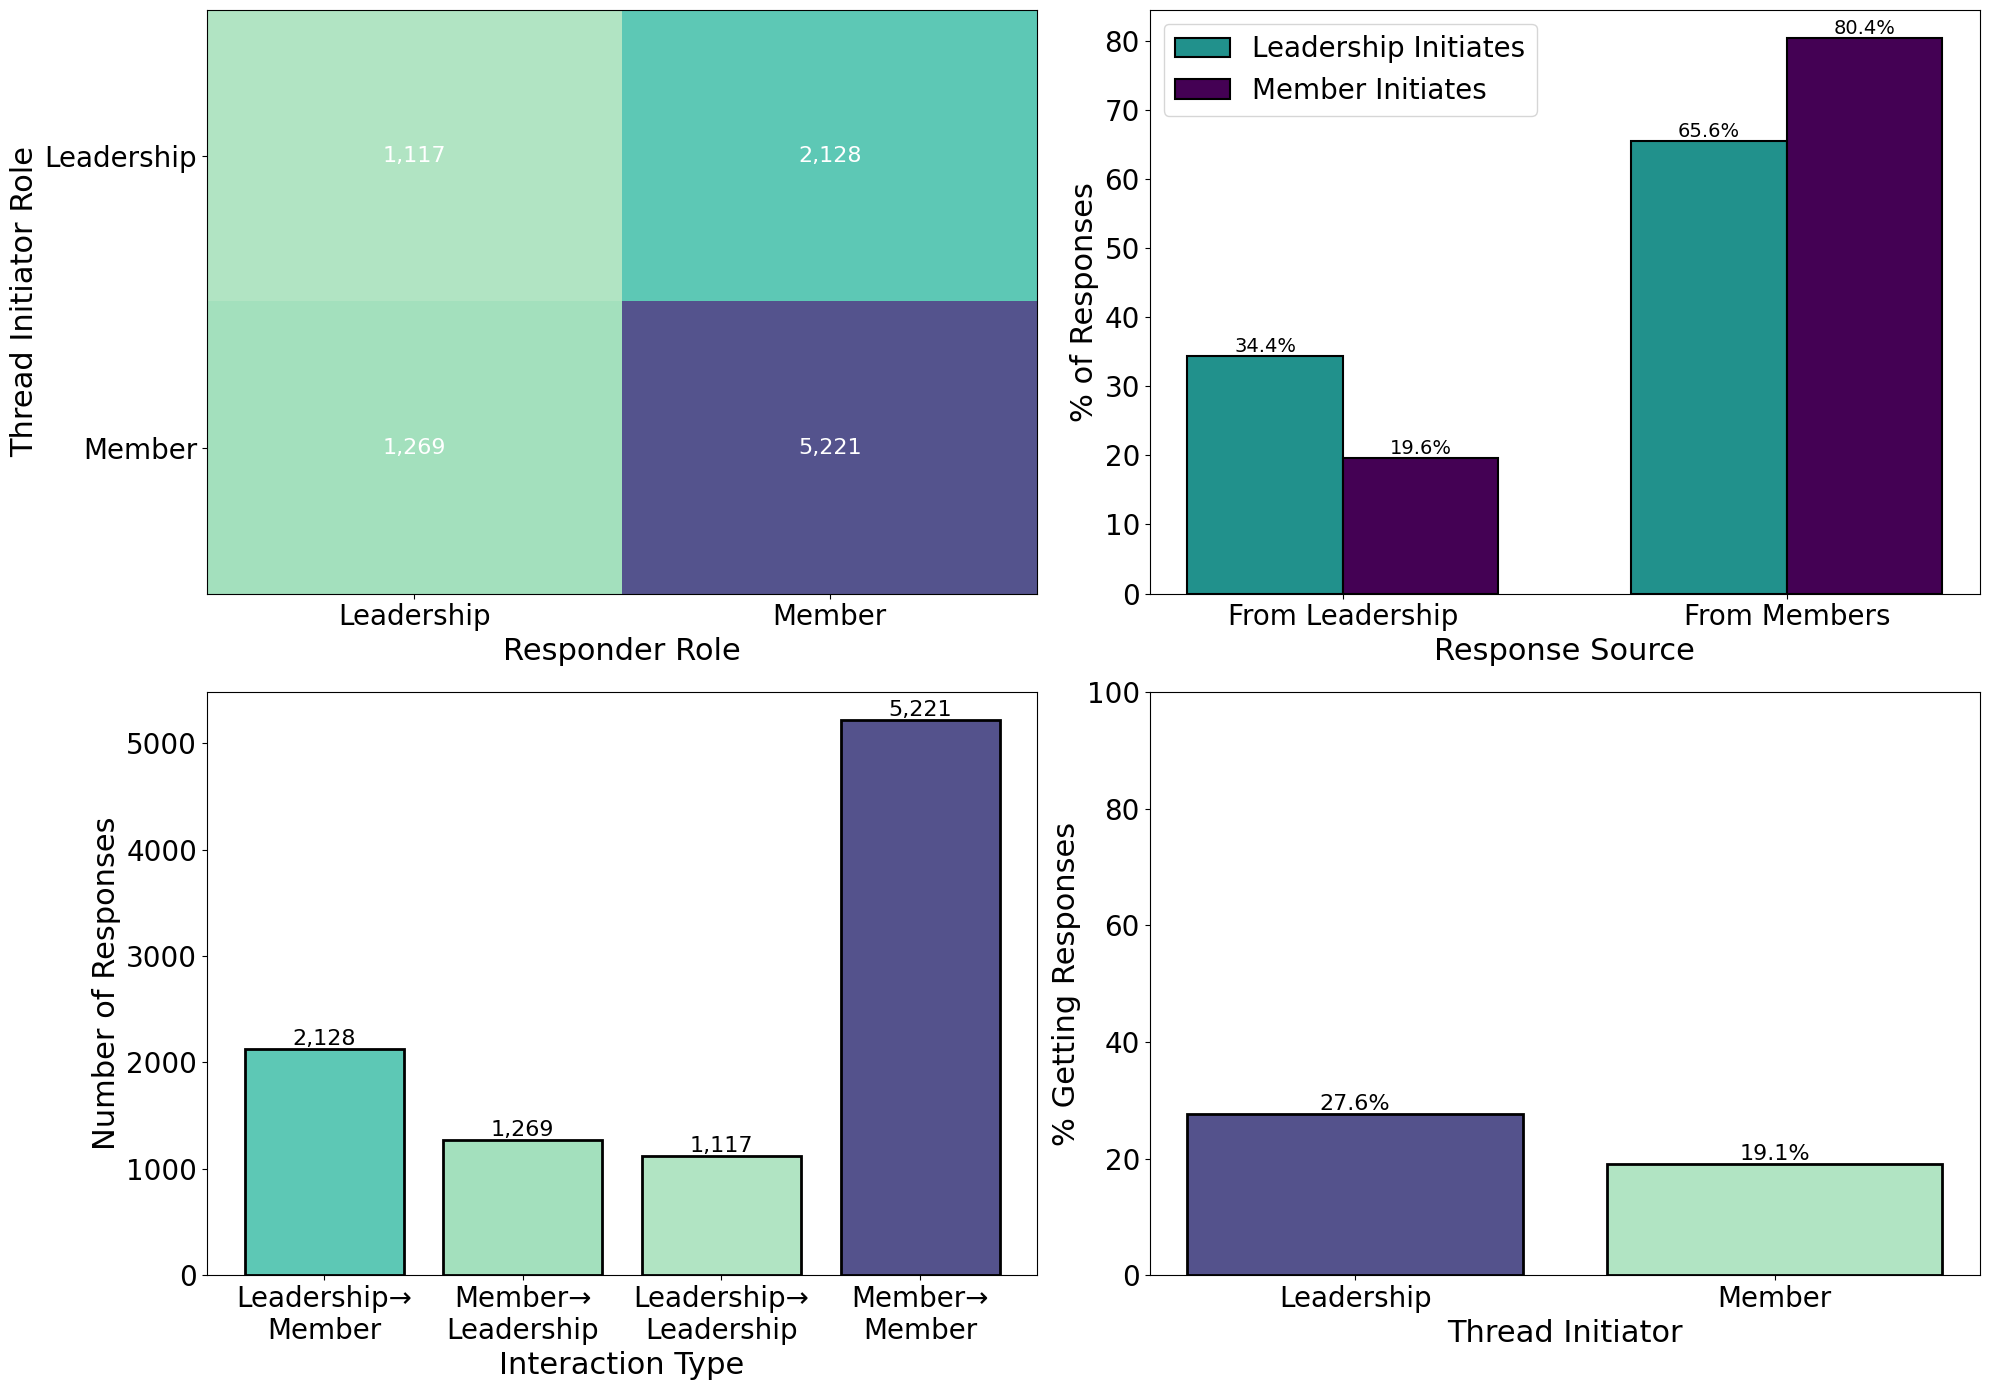

Saved: artifacts/slack-explore-responsePatterns.png

Response Pattern Statistics:
  Total response pairs:   9,735
  Cross-role responses:   3,397 (34.9%)
  Leadership → Member:    2,128
  Member → Leadership:    1,269
  Accessibility ratio:    0.60x


In [7]:
threaded = df[df['thread_ts'].notna()].copy().sort_values(['thread_ts', 'ts'])

response_pairs = []
for thread_id, thread_msgs in threaded.groupby('thread_ts'):
    msgs = thread_msgs.sort_values('ts').reset_index(drop=True)
    if len(msgs) < 2:
        continue
    init_role = msgs.iloc[0]['role']
    for i in range(1, len(msgs)):
        response_pairs.append({
            'initiator_role': init_role,
            'responder_role': msgs.iloc[i]['role']
        })

pairs_df = pd.DataFrame(response_pairs)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Panel A: Response matrix heatmap
ax = axes[0, 0]
response_matrix = pd.crosstab(pairs_df['initiator_role'], pairs_df['responder_role'])
im = ax.imshow(response_matrix.values, cmap=MAKO, aspect='auto')
ax.set_xticks(np.arange(len(response_matrix.columns)))
ax.set_yticks(np.arange(len(response_matrix.index)))
ax.set_xticklabels(response_matrix.columns, fontsize=20)
ax.set_yticklabels(response_matrix.index, fontsize=20)
ax.set_xlabel('Responder Role', fontsize=22)
ax.set_ylabel('Thread Initiator Role', fontsize=22)
for i in range(len(response_matrix.index)):
    for j in range(len(response_matrix.columns)):
        ax.text(j, i, f'{response_matrix.values[i, j]:,}',
                ha='center', va='center', color='w', fontsize=16)

# Panel B: Response composition by initiator
ax = axes[0, 1]
response_pcts = {}
for init_role in ['Leadership', 'Member']:
    role_resp = pairs_df[pairs_df['initiator_role']==init_role]['responder_role'].value_counts()
    tot = role_resp.sum()
    response_pcts[init_role] = {
        'Leadership': role_resp.get('Leadership', 0) / tot * 100 if tot > 0 else 0,
        'Member':     role_resp.get('Member', 0)     / tot * 100 if tot > 0 else 0
    }
x = np.arange(2)
width = 0.35
lead_gets = [response_pcts['Leadership']['Leadership'], response_pcts['Leadership']['Member']]
memb_gets = [response_pcts['Member']['Leadership'],     response_pcts['Member']['Member']]
bars1 = ax.bar(x - width/2, lead_gets, width, label='Leadership Initiates',
               color="#21918c", edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, memb_gets, width, label='Member Initiates',
               color="#440154", edgecolor='black', linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels(['From Leadership', 'From Members'], fontsize=20)
ax.set_xlabel('Response Source', fontsize=22)
ax.set_ylabel('% of Responses', fontsize=22)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=20)
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=14)

# Panel C: Directional cross-role interaction counts
ax = axes[1, 0]
cross_l_m = pairs_df[(pairs_df['initiator_role']=='Leadership') & (pairs_df['responder_role']=='Member')].shape[0]
cross_m_l = pairs_df[(pairs_df['initiator_role']=='Member')     & (pairs_df['responder_role']=='Leadership')].shape[0]
same_l    = pairs_df[(pairs_df['initiator_role']=='Leadership') & (pairs_df['responder_role']=='Leadership')].shape[0]
same_m    = pairs_df[(pairs_df['initiator_role']=='Member')     & (pairs_df['responder_role']=='Member')].shape[0]
categories = ['Leadership→\nMember', 'Member→\nLeadership', 'Leadership→\nLeadership', 'Member→\nMember']
vals = np.array([cross_l_m, cross_m_l, same_l, same_m])
bars = ax.bar(categories, vals, color=vir(vals), edgecolor='black', linewidth=2)
ax.set_xlabel('Interaction Type', fontsize=22)
ax.set_ylabel('Number of Responses', fontsize=22)
ax.tick_params(axis='both', labelsize=20)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h,
            f'{int(h):,}', ha='center', va='bottom', fontsize=16)

# Panel D: Thread response rate
ax = axes[1, 1]
threads_started   = df[df['thread_ts'].isna()].groupby('role').size()
thread_initiators = threaded.groupby('thread_ts').first()['role']
threads_got_resp  = thread_initiators.value_counts()
response_rate = {}
for role in ['Leadership', 'Member']:
    started  = threads_started.get(role, 0)
    got_resp = threads_got_resp.get(role, 0)
    response_rate[role] = got_resp / started * 100 if started > 0 else 0
vals = np.array([response_rate['Leadership'], response_rate['Member']])
bars = ax.bar(['Leadership', 'Member'], vals, color=vir(vals), edgecolor='black', linewidth=2)
ax.set_xlabel('Thread Initiator', fontsize=22)
ax.set_ylabel('% Getting Responses', fontsize=22)
ax.tick_params(axis='both', labelsize=20)
ax.set_ylim(0, 100)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=16)

plt.tight_layout()
plt.savefig('artifacts/slack-explore-responsePatterns.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: artifacts/slack-explore-responsePatterns.png')

print(f'\nResponse Pattern Statistics:')
print(f'  Total response pairs:   {len(pairs_df):,}')
print(f'  Cross-role responses:   {cross_l_m + cross_m_l:,} ({(cross_l_m + cross_m_l)/len(pairs_df)*100:.1f}%)')
print(f'  Leadership → Member:    {cross_l_m:,}')
print(f'  Member → Leadership:    {cross_m_l:,}')
print(f'  Accessibility ratio:    {cross_m_l/cross_l_m:.2f}x')

## Exploration: Network Centrality (Thread Co-participation)

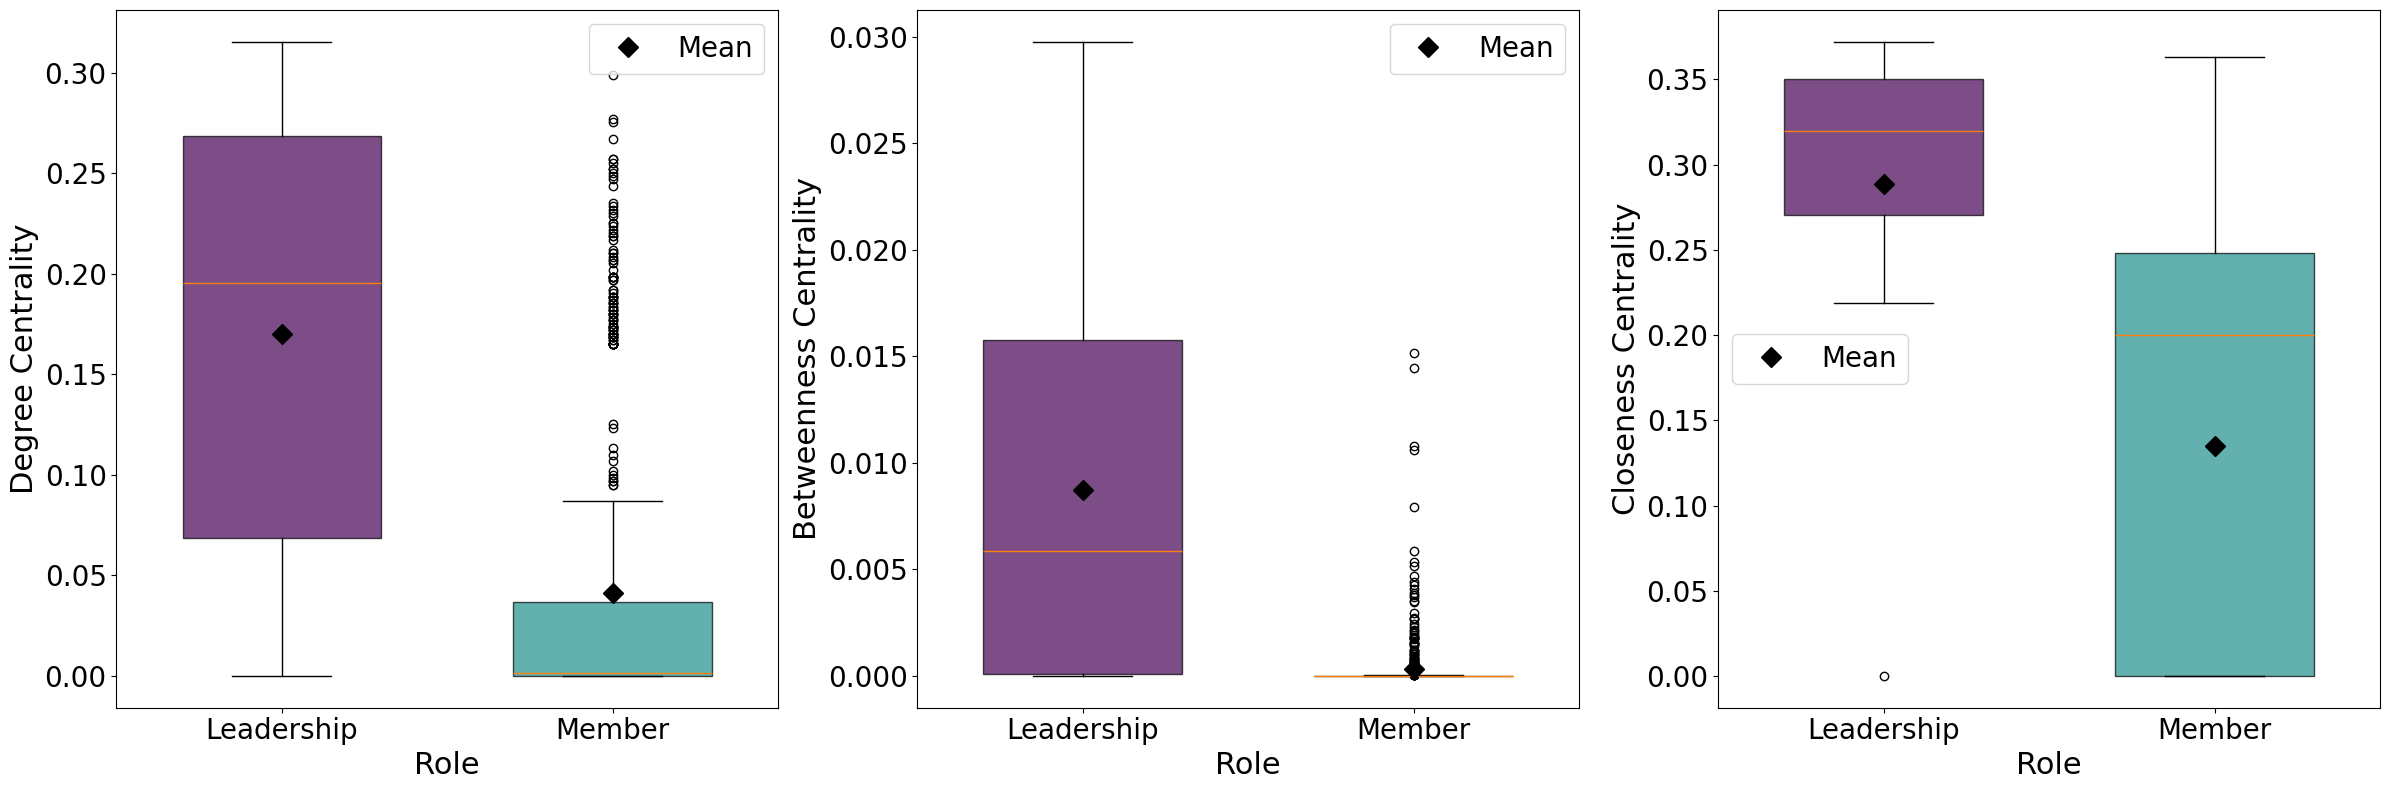

Saved: artifacts/slack-explore-networkCentrality.png

  Degree Centrality:
    Leadership — mean: 0.1703, median: 0.1953
    Member     — mean: 0.0413, median: 0.0017

  Betweenness Centrality:
    Leadership — mean: 0.0087, median: 0.0059
    Member     — mean: 0.0003, median: 0.0000

  Closeness Centrality:
    Leadership — mean: 0.2886, median: 0.3200
    Member     — mean: 0.1352, median: 0.1999


In [8]:
# Build graph
G = nx.Graph()
for user in df['id'].unique():
    role = df[df['id']==user]['role'].iloc[0]
    G.add_node(user, role=role)

threaded = df[df['thread_ts'].notna()]
for participants in threaded.groupby('thread_ts')['id'].apply(list):
    if len(participants) > 1:
        for i in range(len(participants)):
            for j in range(i+1, len(participants)):
                if G.has_edge(participants[i], participants[j]):
                    G[participants[i]][participants[j]]['weight'] += 1
                else:
                    G.add_edge(participants[i], participants[j], weight=1)

degree_cent     = nx.degree_centrality(G)
between_cent    = nx.betweenness_centrality(G)
closeness_cent  = nx.closeness_centrality(G)

centrality_by_role = defaultdict(lambda: {'degree': [], 'betweenness': [], 'closeness': []})
for node in G.nodes():
    role = G.nodes[node].get('role', 'Unknown')
    if role in ['Leadership', 'Member']:
        centrality_by_role[role]['degree'].append(degree_cent.get(node, 0))
        centrality_by_role[role]['betweenness'].append(between_cent.get(node, 0))
        centrality_by_role[role]['closeness'].append(closeness_cent.get(node, 0))

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

metrics = [
    ('degree',      'Degree Centrality'),
    ('betweenness', 'Betweenness Centrality'),
    ('closeness',   'Closeness Centrality'),
]

for ax, (metric, label) in zip(axes, metrics):
    lead_vals = centrality_by_role['Leadership'][metric]
    memb_vals = centrality_by_role['Member'][metric]

    bp = ax.boxplot([lead_vals, memb_vals], labels=['Leadership', 'Member'],
                    patch_artist=True, widths=0.6)

    med_lead = np.median(lead_vals)
    med_memb = np.median(memb_vals)
    med_max  = max(med_lead, med_memb) + 1e-9
    for patch, med in zip(bp['boxes'], [med_lead, med_memb]):
        patch.set_facecolor(["#440154", "#21918c"][list(bp["boxes"]).index(patch)])
        patch.set_alpha(0.7)

    # Mean diamonds — black per colorblind-accessibility convention
    means = [np.mean(lead_vals), np.mean(memb_vals)]
    ax.plot([1, 2], means, 'D', color='black', markersize=10, label='Mean', zorder=3)

    ax.set_xlabel('Role', fontsize=22)
    ax.set_ylabel(label, fontsize=22)
    ax.tick_params(axis='both', labelsize=20)
    ax.legend(fontsize=20)

plt.tight_layout()
plt.savefig('artifacts/slack-explore-networkCentrality.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: artifacts/slack-explore-networkCentrality.png')

for metric, label in metrics:
    lead_vals = centrality_by_role['Leadership'][metric]
    memb_vals = centrality_by_role['Member'][metric]
    print(f'\n  {label}:')
    print(f'    Leadership — mean: {np.mean(lead_vals):.4f}, median: {np.median(lead_vals):.4f}')
    print(f'    Member     — mean: {np.mean(memb_vals):.4f}, median: {np.median(memb_vals):.4f}')

## Exploration: Temporal Participation

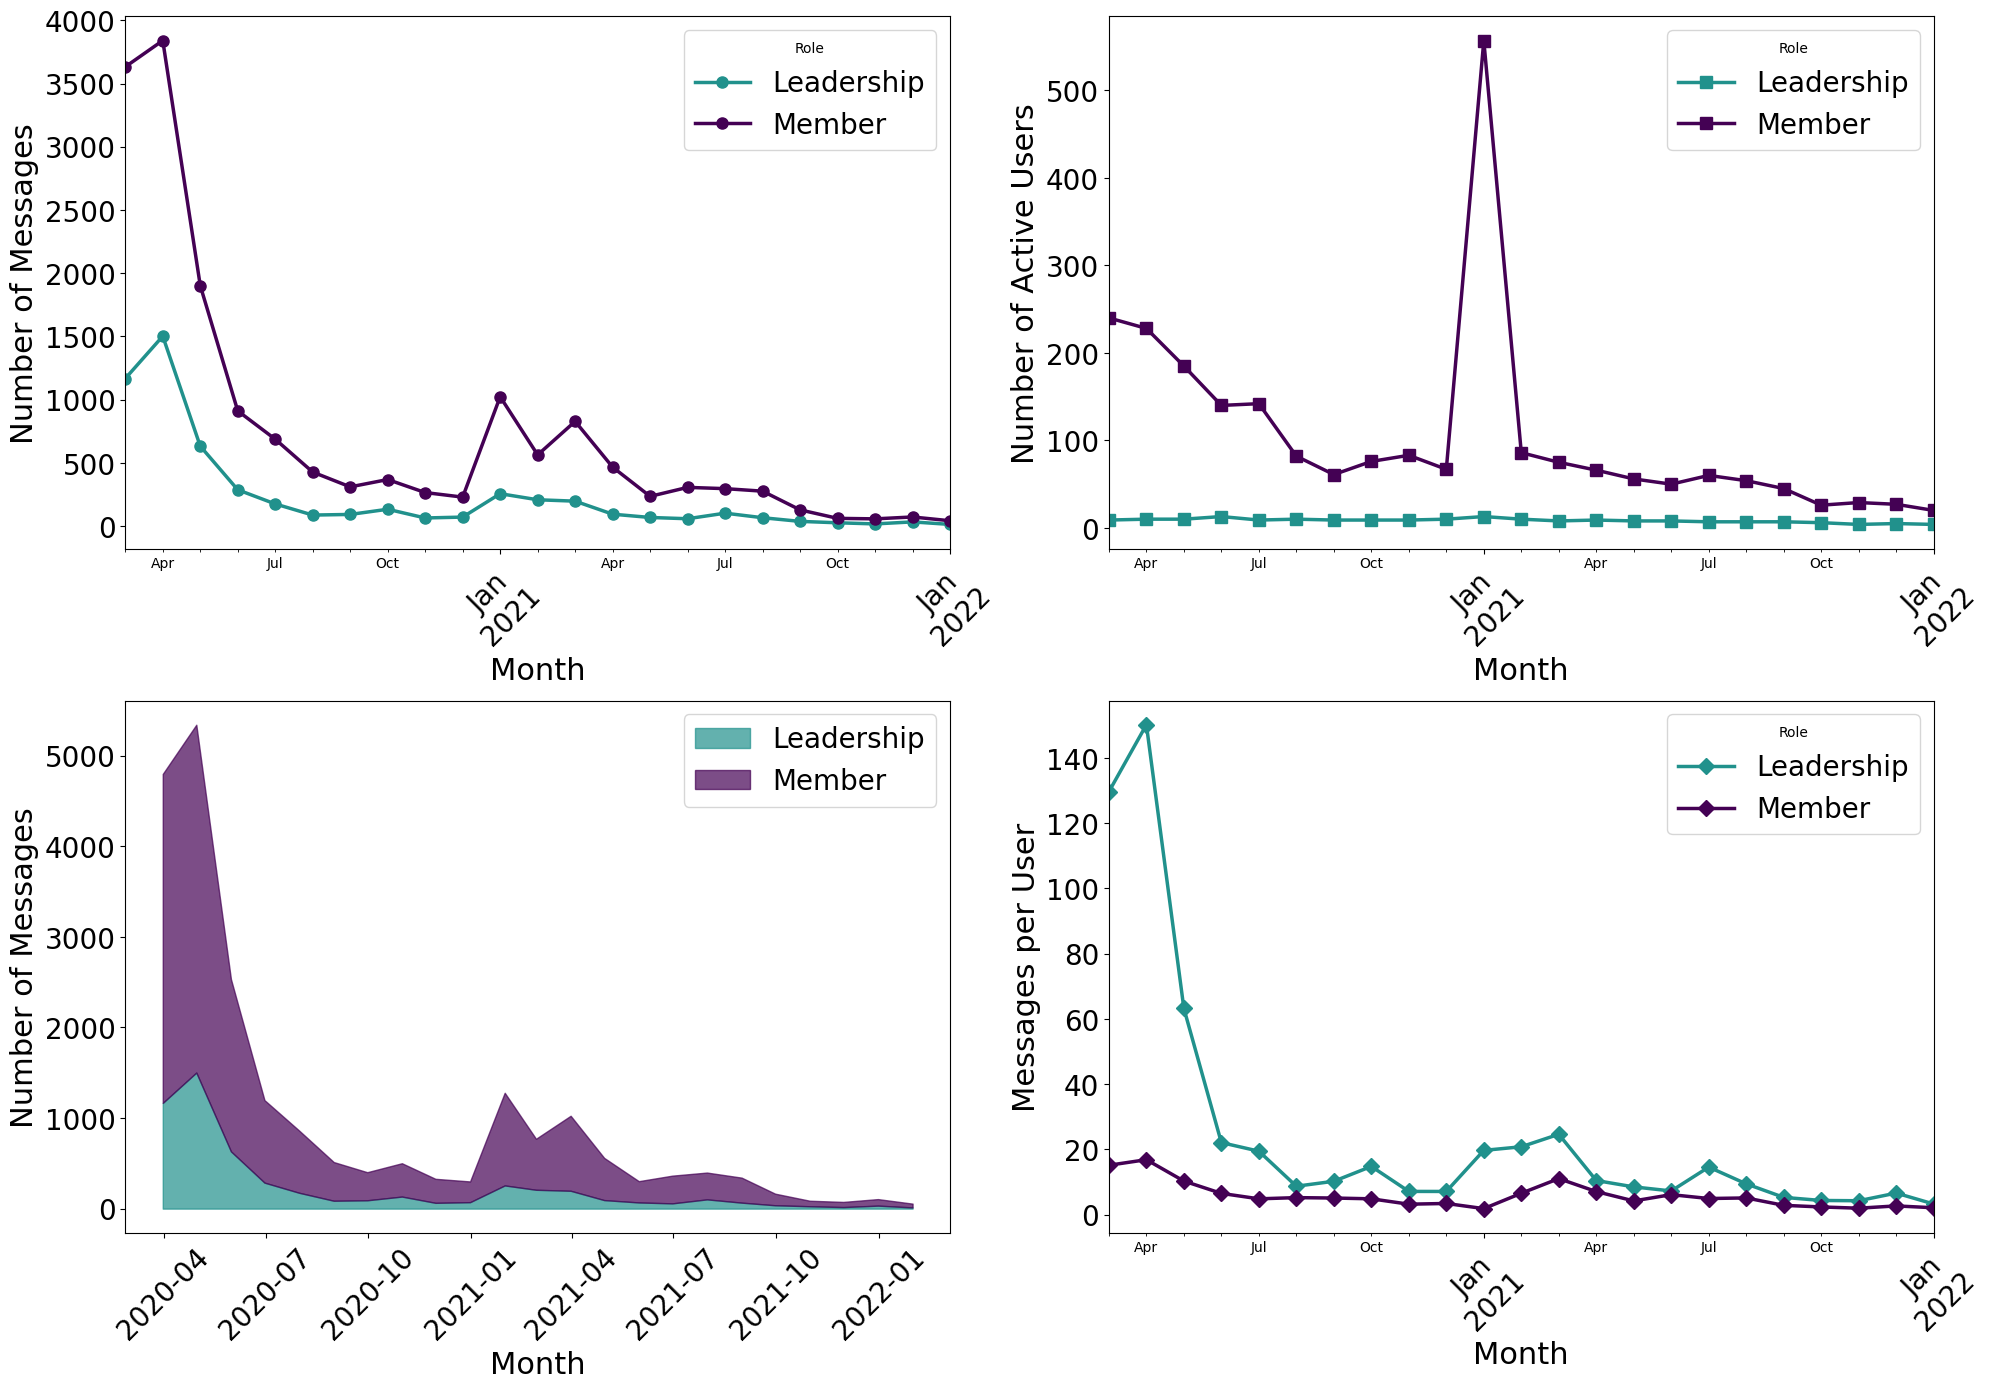

Saved: artifacts/slack-explore-participation.png


In [9]:
monthly_activity = df.groupby([pd.Grouper(key='date', freq='M'), 'role']).size().unstack(fill_value=0)
monthly_users    = df.groupby([pd.Grouper(key='date', freq='M'), 'role'])['id'].nunique().unstack(fill_value=0)
msgs_per_capita  = monthly_activity / monthly_users

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Panel A: Monthly messages by role
ax = axes[0, 0]
monthly_activity.plot(kind='line', ax=ax, marker='o', linewidth=2.5, markersize=8,
                      color=["#21918c", "#440154"])
ax.set_xlabel('Month', fontsize=22)
ax.set_ylabel('Number of Messages', fontsize=22)
ax.tick_params(axis='both', labelsize=20)
ax.legend(title='Role', fontsize=20)
plt.setp(ax.get_xticklabels(), rotation=45)

# Panel B: Active users by role
ax = axes[0, 1]
monthly_users.plot(kind='line', ax=ax, marker='s', linewidth=2.5, markersize=8,
                   color=["#21918c", "#440154"])
ax.set_xlabel('Month', fontsize=22)
ax.set_ylabel('Number of Active Users', fontsize=22)
ax.tick_params(axis='both', labelsize=20)
ax.legend(title='Role', fontsize=20)
plt.setp(ax.get_xticklabels(), rotation=45)

# Panel C: Stacked area
ax = axes[1, 0]
ax.fill_between(monthly_activity.index, 0, monthly_activity['Leadership'],
                label='Leadership', alpha=0.7, color="#21918c")
ax.fill_between(monthly_activity.index,
                monthly_activity['Leadership'],
                monthly_activity['Leadership'] + monthly_activity['Member'],
                label='Member', alpha=0.7, color="#440154")
ax.set_xlabel('Month', fontsize=22)
ax.set_ylabel('Number of Messages', fontsize=22)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=20)
plt.setp(ax.get_xticklabels(), rotation=45)

# Panel D: Per capita messages
ax = axes[1, 1]
msgs_per_capita.plot(kind='line', ax=ax, marker='D', linewidth=2.5, markersize=8,
                     color=["#21918c", "#440154"])
ax.set_xlabel('Month', fontsize=22)
ax.set_ylabel('Messages per User', fontsize=22)
ax.tick_params(axis='both', labelsize=20)
ax.legend(title='Role', fontsize=20)
plt.setp(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('artifacts/slack-explore-participation.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: artifacts/slack-explore-participation.png')

## Exploration: Geographic Diversity (Bar Charts)

In [10]:
country_stats = df.groupby("country").agg(
    Total_Messages=("id", "count"),
    Unique_Users=("id", "nunique"),
    Active_Days=("date", "nunique")
).reset_index()

country_stats["Messages_per_User"]    = country_stats["Total_Messages"] / country_stats["Unique_Users"]
country_stats["Messages_per_Day"]     = country_stats["Total_Messages"] / country_stats["Active_Days"]
country_stats["Active_Days_per_User"] = country_stats["Active_Days"]    / country_stats["Unique_Users"]

country_stats = country_stats.sort_values("Unique_Users", ascending=False)

# Filter: >= 5 unique users
country_stats_filtered = country_stats[country_stats["Unique_Users"] >= 5].copy()

print("Top 15 countries by sub-population size:")
print(country_stats.head(15)[["country", "Total_Messages", "Unique_Users", "Messages_per_User"]].to_string(index=False))


Top 15 countries by sub-population size:
       country  Total_Messages  Unique_Users  Messages_per_User
 United States            7540           202          37.326733
   Netherlands            2409            48          50.187500
        France             784            41          19.121951
United Kingdom            2479            34          72.911765
         Italy            1732            32          54.125000
        Canada             229            18          12.722222
       Germany            1268            17          74.588235
       Belgium             244            16          15.250000
         India             792            13          60.923077
         Japan             169            13          13.000000
        Turkey            1132            10         113.200000
        Israel             725            10          72.500000
          Iran              97             9          10.777778
     Australia             211             9          23.444444

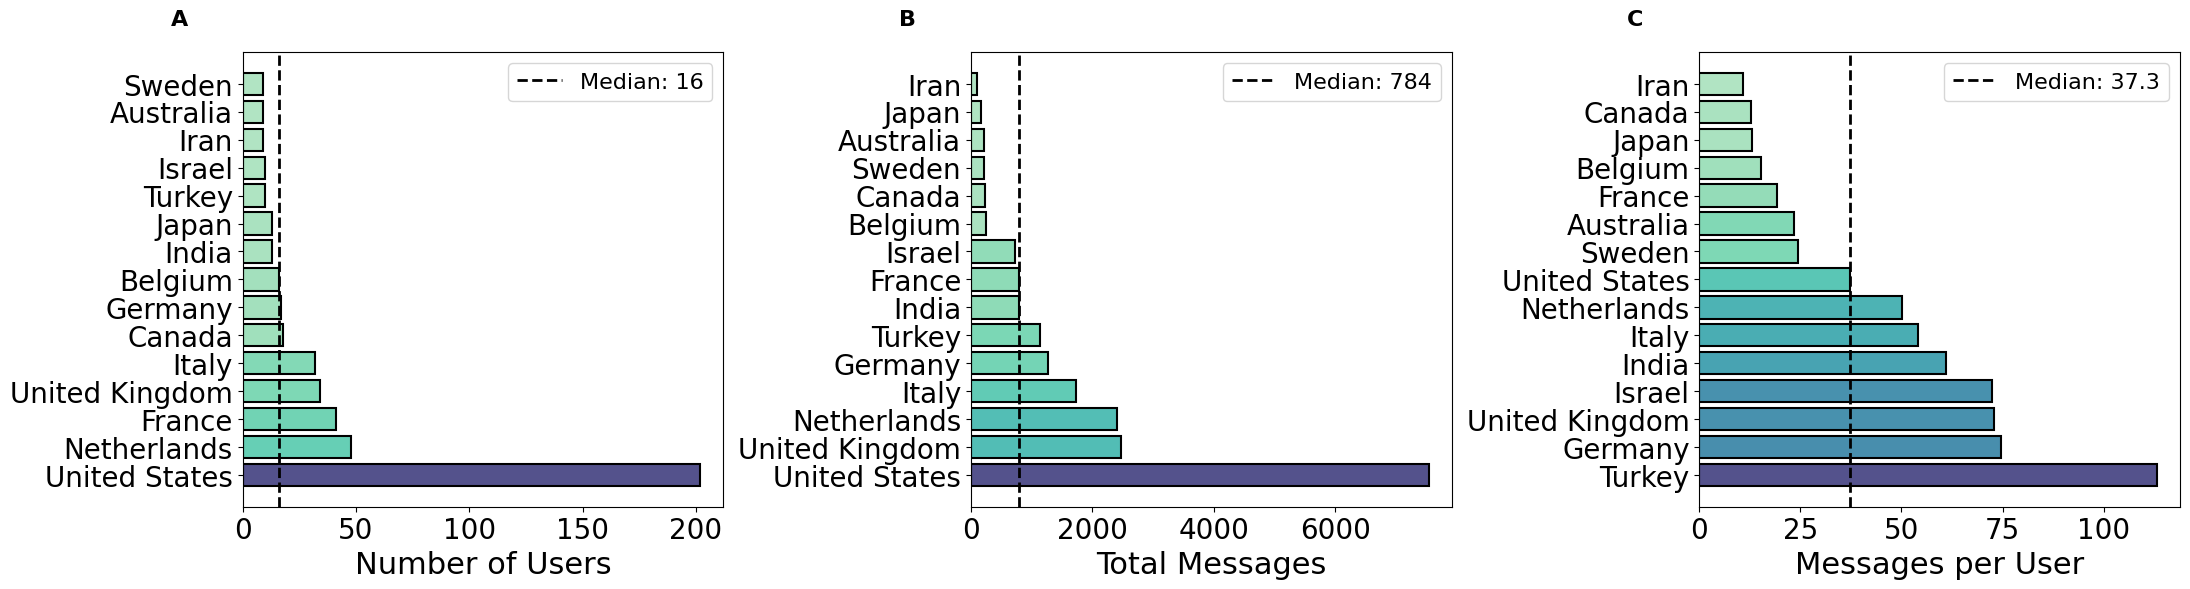

Saved: artifacts/slack-explore-diversity-threepanel.png


In [11]:
top_countries = country_stats_filtered.sort_values("Unique_Users", ascending=False).head(15).copy()

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Panel A: Sub-population size (denominator — who is here)
ax = axes[0]
top_a = top_countries.sort_values("Unique_Users", ascending=False)
vals = top_a["Unique_Users"].values
ax.barh(top_a["country"], vals, color=vir(vals), edgecolor="black", linewidth=1.5)
ax.set_xlabel("Number of Users", fontsize=22)
ax.tick_params(axis="both", labelsize=20)
median_a = top_a["Unique_Users"].median()
ax.axvline(x=median_a, color="black", linestyle="--", linewidth=2, label=f"Median: {median_a:.0f}")
ax.legend(fontsize=16)

# Panel B: Raw message counts (numerator — who is talking)
ax = axes[1]
top_b = top_countries.sort_values("Total_Messages", ascending=False)
vals = top_b["Total_Messages"].values
ax.barh(top_b["country"], vals, color=vir(vals), edgecolor="black", linewidth=1.5)
ax.set_xlabel("Total Messages", fontsize=22)
ax.tick_params(axis="both", labelsize=20)
median_b = top_b["Total_Messages"].median()
ax.axvline(x=median_b, color="black", linestyle="--", linewidth=2, label=f"Median: {median_b:.0f}")
ax.legend(fontsize=16)

# Panel C: Population-corrected engagement (A/B — who talks relative to presence)
ax = axes[2]
top_c = top_countries.sort_values("Messages_per_User", ascending=False)
vals = top_c["Messages_per_User"].values
ax.barh(top_c["country"], vals, color=vir(vals), edgecolor="black", linewidth=1.5)
ax.set_xlabel("Messages per User", fontsize=22)
ax.tick_params(axis="both", labelsize=20)
median_c = top_countries["Messages_per_User"].median()
ax.axvline(x=median_c, color="black", linestyle="--", linewidth=2, label=f"Median: {median_c:.1f}")
ax.legend(fontsize=16)

# Panel labels — bold corner style matching R cowplot AUTO
for ax, label in zip(axes, ["A", "B", "C"]):
    ax.text(-0.15, 1.05, label, transform=ax.transAxes,
            fontsize=16, fontweight="bold", va="bottom", ha="left")

plt.tight_layout()
plt.savefig(os.path.join("artifacts", "slack-explore-diversity-threepanel.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: artifacts/slack-explore-diversity-threepanel.png")


## Exploration: Engagement vs Sub-Population Size (Bubble Chart)

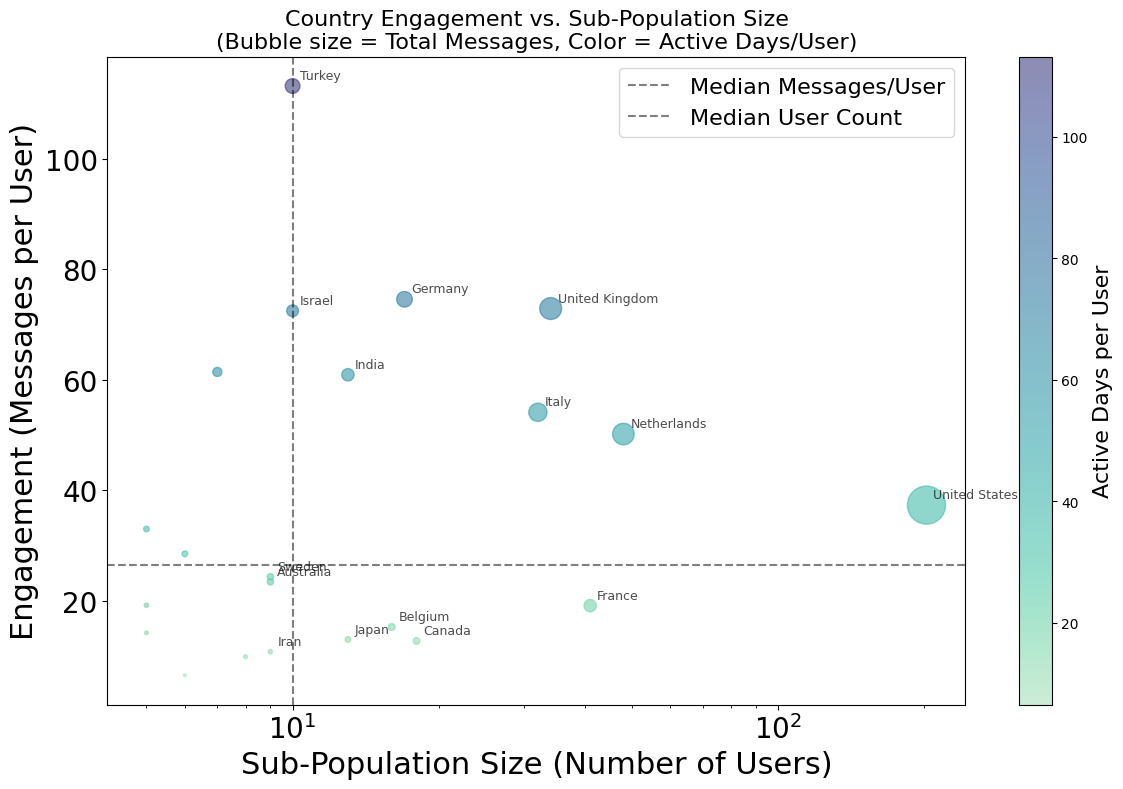

Saved: artifacts/slack-explore-diversity-bubble.png


In [12]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    country_stats_filtered["Unique_Users"],
    country_stats_filtered["Messages_per_User"],
    s=country_stats_filtered["Total_Messages"] / 10,
    alpha=0.6,
    c=country_stats_filtered["Active_Days_per_User"],
    cmap=MAKO
)

# Labels for top contributors
for idx, row in country_stats_filtered.head(15).iterrows():
    ax.annotate(row["country"],
                (row["Unique_Users"], row["Messages_per_User"]),
                fontsize=9, alpha=0.7, xytext=(5, 5), textcoords="offset points")

# Median reference lines — black
ax.axhline(y=country_stats_filtered["Messages_per_User"].median(),
           color="black", linestyle="--", alpha=0.5, label="Median Messages/User")
ax.axvline(x=country_stats_filtered["Unique_Users"].median(),
           color="black", linestyle="--", alpha=0.5, label="Median User Count")

ax.set_xlabel("Sub-Population Size (Number of Users)", fontsize=22)
ax.set_ylabel("Engagement (Messages per User)", fontsize=22)
ax.set_title("Country Engagement vs. Sub-Population Size\n"
             "(Bubble size = Total Messages, Color = Active Days/User)", fontsize=16)
ax.set_xscale("log")
ax.tick_params(axis="both", labelsize=20)
ax.legend(fontsize=16)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Active Days per User", fontsize=16)

plt.tight_layout()
plt.savefig(os.path.join("artifacts", "slack-explore-diversity-bubble.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: artifacts/slack-explore-diversity-bubble.png")
